# Physical Track Analysis — SLSNe Detection with Rubin LSST

Parallel to `analysis_multimodel_comparison.ipynb` (GP track).
Physical templates use MOSFiT posteriors (Gómez+2024), full SED synthesis via `synthesize_mag_at_z()`. Valid z=0.1–5.0.

GP canonical runs (260409) are untouched by this notebook.

**Reload flags:** Templates NO — Population NO — Mag grid NO (not used in physical path)

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
MODELS = [
    'naive_physical',
    'o_dependent_physical',
    'fe_dependent_physical',
]
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'baseline_v5.3.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs',
]
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 5.0

# --- Paths ---
SHARED_DIR   = get_shared_output_dir('SLSNe')
ADAPTIVE_DIR = REPO / 'output/SLSNe/adaptive'

# --- Load adaptive efficiency results ---
# Each model has one adaptive_results.csv with columns:
#   z_lo, z_hi, cadence, metric, n_events, n_success, efficiency, sigma
print('=== Adaptive Results Check ===')
ADAPTIVE = {}
for model in MODELS:
    csv = ADAPTIVE_DIR / f'{model}_adaptive_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        ADAPTIVE[model] = df
        zmax = df['z_hi'].max()
        n_bins = df['z_hi'].nunique()
        print(f'  OK  {model}: {n_bins} z-bins, z_max={zmax:.1f}')
    else:
        print(f'  MISSING  {model}: {csv}')

print(f'\nLoaded {len(ADAPTIVE)}/{len(MODELS)} adaptive result files')
#

=== Adaptive Results Check ===
  OK  naive_physical: 14 z-bins, z_max=1.5
  OK  o_dependent_physical: 14 z-bins, z_max=1.5
  OK  fe_dependent_physical: 16 z-bins, z_max=1.7

Loaded 3/3 adaptive result files


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_physical.png


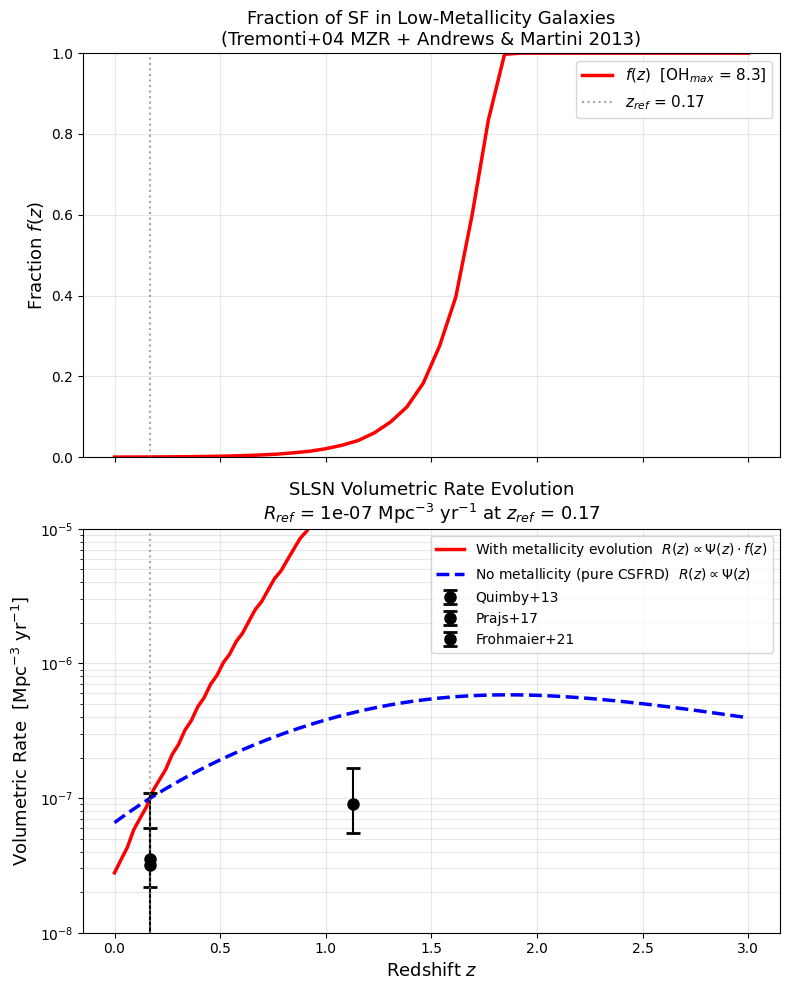

Saved: rate_evolution_comparison_physical.png


In [2]:
# ============================================================================
# CELL A: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR x metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / 'rate_evolution_comparison_physical.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [3]:
# ============================================================================
# CELL 6: Build per-model efficiency data from adaptive results CSV
# No population pkl or .npy loading needed — adaptive CSV has everything.
# Builds pop_data dict compatible with downstream plotting cells.
# ============================================================================

METRIC_MAP = {
    'detect':       'SLSN_Detect_Physical_Metric',
    'characterize': 'SLSN_Characterize_Physical_Metric',
    'villar':       'SLSN_Villar_Physical_Metric',
    'elasticc':     'SLSN_ELAsTiCC_Metric',
    'spectrigger':  'SLSN_SpecTrigger_Physical_Metric',
}
METRIC_KEYS = list(METRIC_MAP.keys())

pop_data = {}

for model in MODELS:
    if model not in ADAPTIVE:
        print(f'Skipping {model} — no adaptive results')
        continue

    df = ADAPTIVE[model]
    print(f'\n{model}:')

    metric_arrays = {m: {} for m in METRIC_KEYS}
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    for short, full in METRIC_MAP.items():
        for cadence in CADENCES:
            sub = df[(df['metric']==full) & (df['cadence']==cadence)].copy()
            if sub.empty:
                metric_arrays[short][cadence] = None
                continue
            # Use z_lo+z_hi as lookup keys — one row per z-bin per cadence
            eff_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['efficiency']
            ))
            n_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['n_events']
            ))
            metric_arrays[short][cadence] = {
                'z_bins':     [(z0,z1) for z0,z1 in z_bins],
                'efficiency': [float(eff_dict.get((z0,z1), np.nan)) for z0,z1 in z_bins],
                'n_events':   [int(n_dict.get((z0,z1), 0))          for z0,z1 in z_bins],
            }

    z_lo_arr  = np.array([b[0] for b in z_bins])
    z_hi_arr  = np.array([b[1] for b in z_bins])
    z_centers = 0.5 * (z_lo_arr + z_hi_arr)

    pop_data[model] = {
        'z_bins':      z_bins,
        'z_lo':        z_lo_arr,
        'z_hi':        z_hi_arr,
        'z_centers':   z_centers,
        'detect':       metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger':  metric_arrays['spectrigger'],
        'villar':       metric_arrays['villar'],
        'elasticc':     metric_arrays['elasticc'],
    }
    print(f'  z-bins: {len(z_bins)}, cadences with data: {CADENCES}')

print('\n=== Adaptive efficiency data loaded for all models ===')



naive_physical:
  z-bins: 14, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

o_dependent_physical:
  z-bins: 14, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

fe_dependent_physical:
  z-bins: 16, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'poor_weather_v5.0.1_10yrs']

=== Adaptive efficiency data loaded for all models ===


Loading physical templates...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y'], shape=(265, 100, 79), convention=apparent ✓
Templates loaded: 265 events

=== Population diagnostics: naive_physical ===
[LOAD] Loaded 2032193 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive_physical.pkl
[LOAD] z-filtered to 750348 events (z_min=0.1, z_max=2.0)


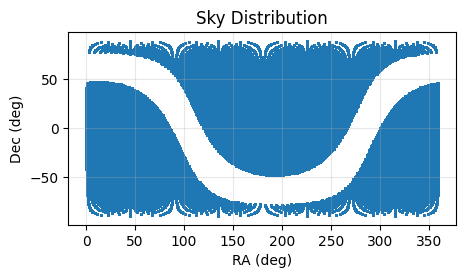

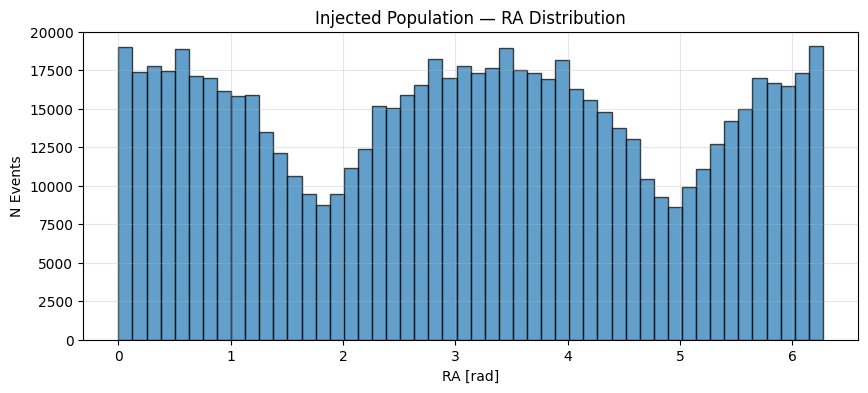

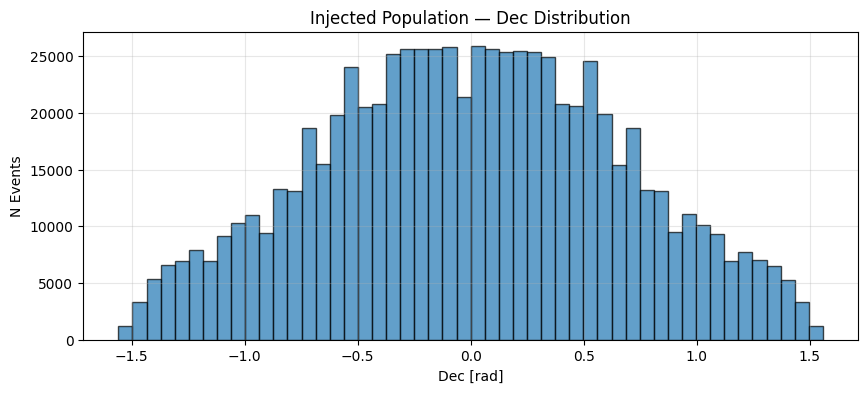

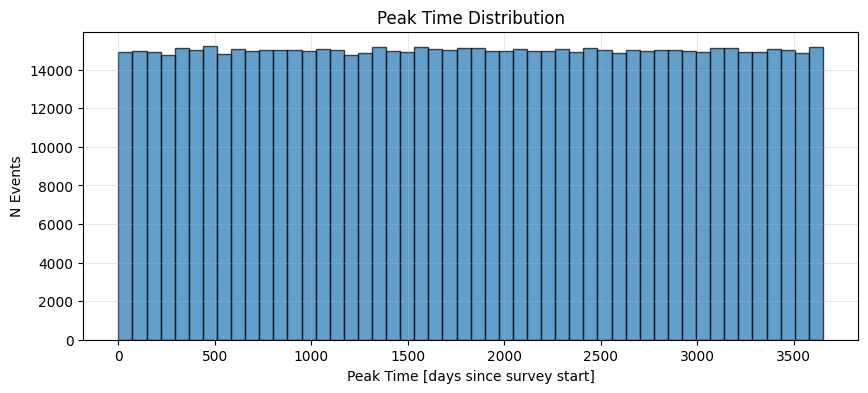

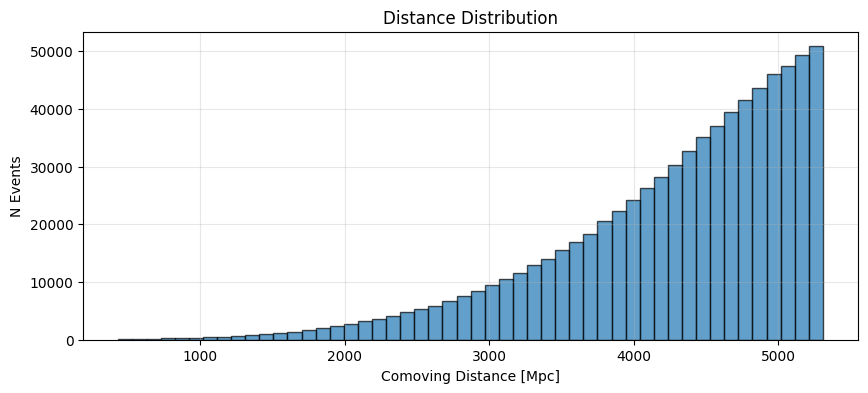

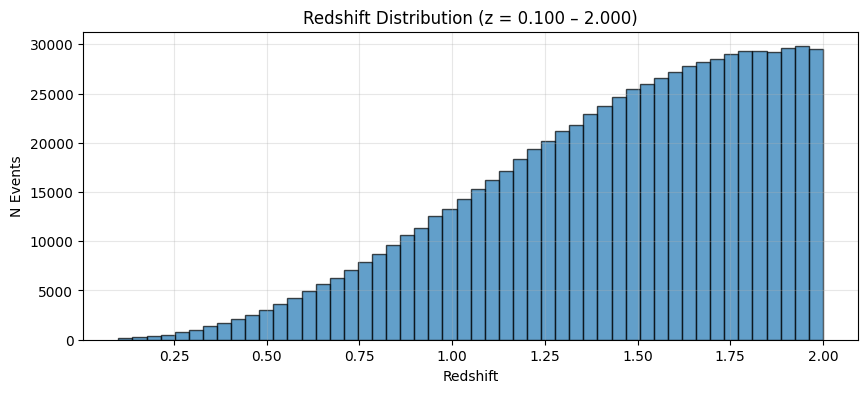

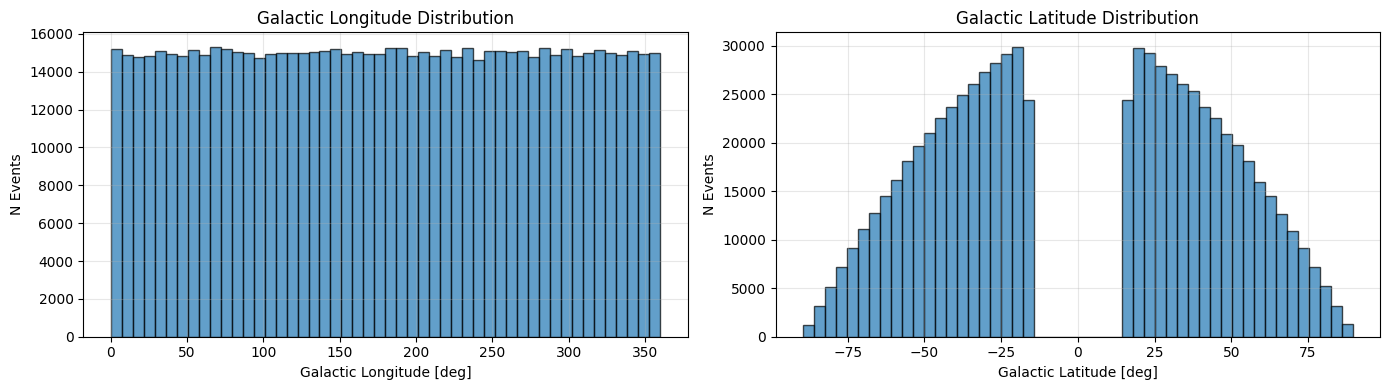

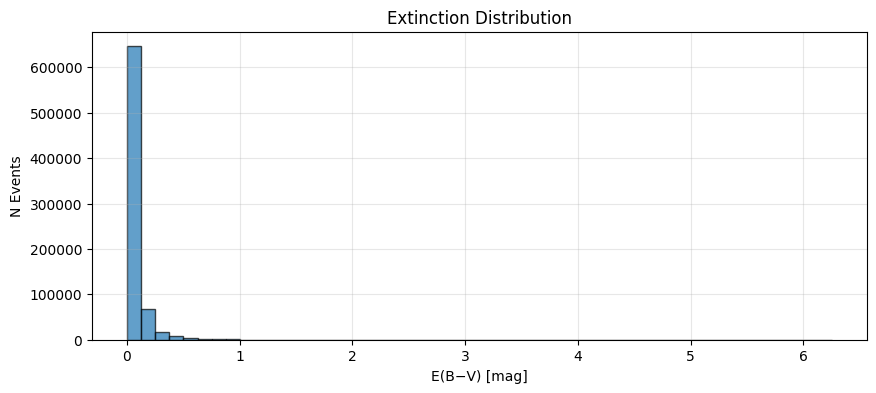

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/naive_physical

=== Population diagnostics: o_dependent_physical ===
[LOAD] Loaded 7035974 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent_physical.pkl
[LOAD] z-filtered to 1144460 events (z_min=0.1, z_max=2.0)


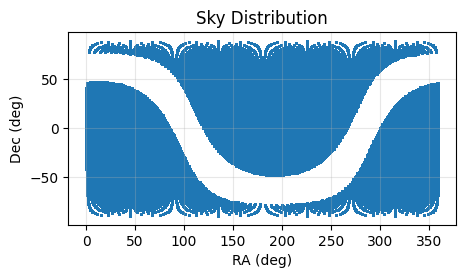

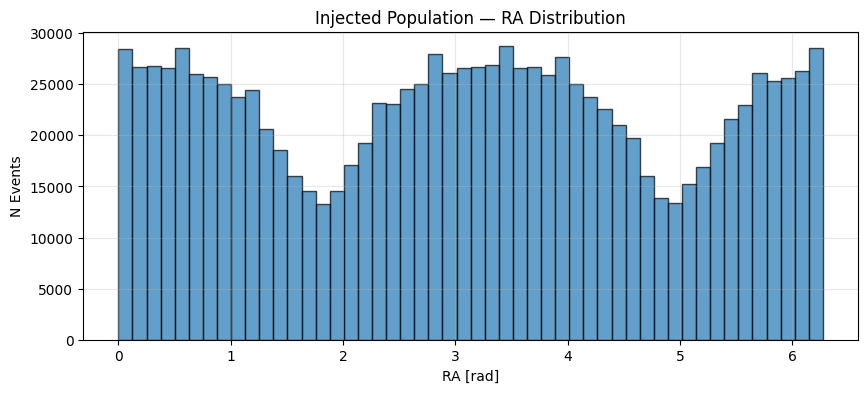

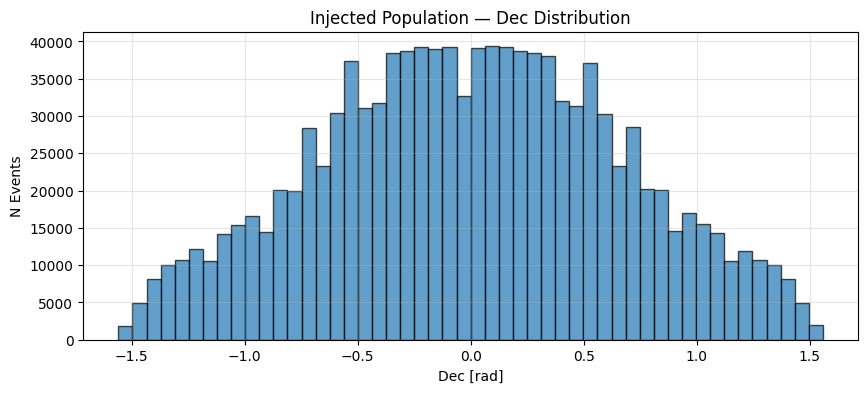

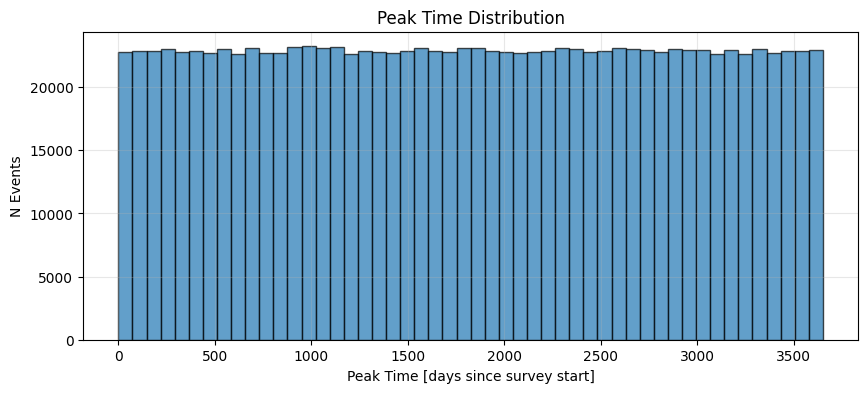

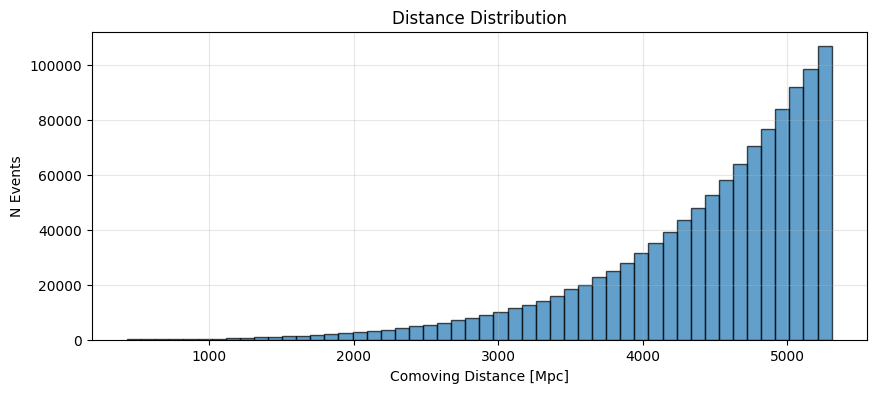

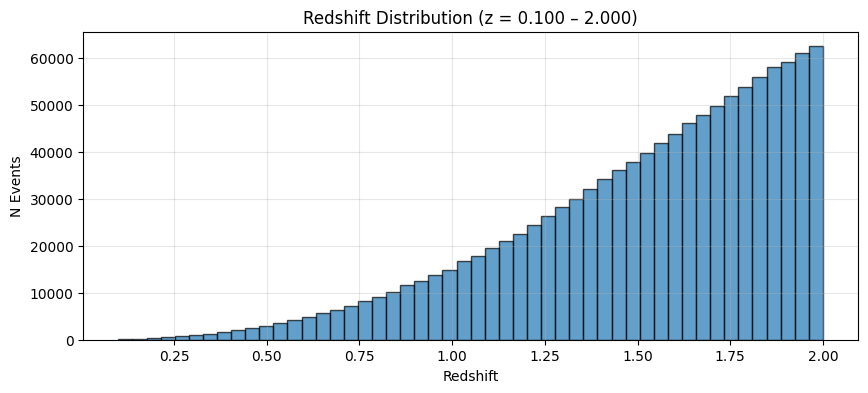

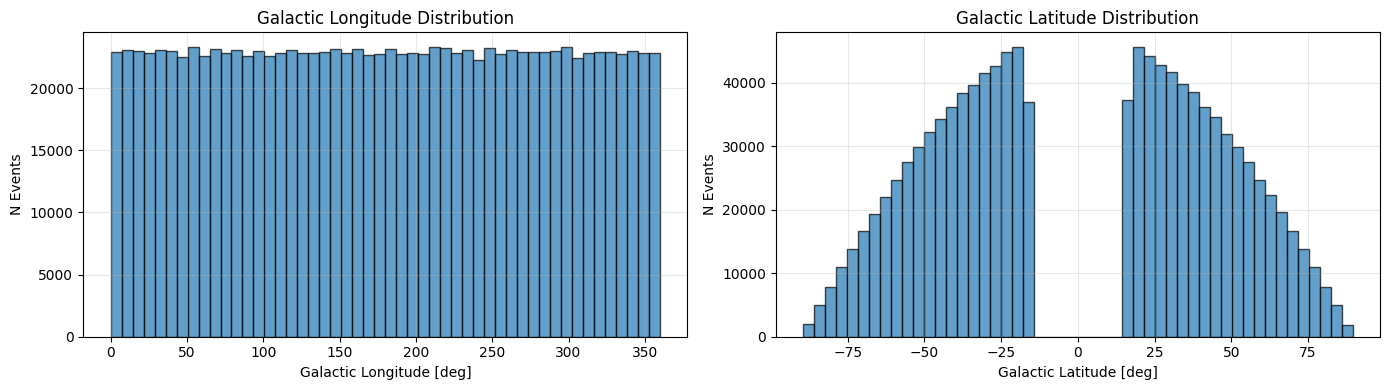

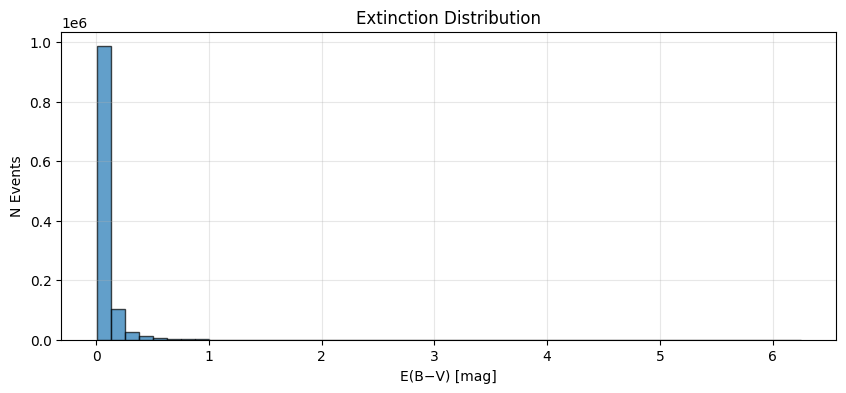

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/o_dependent_physical

=== Population diagnostics: fe_dependent_physical ===
[LOAD] Loaded 14424192 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent_physical.pkl
[LOAD] z-filtered to 2237360 events (z_min=0.1, z_max=2.0)


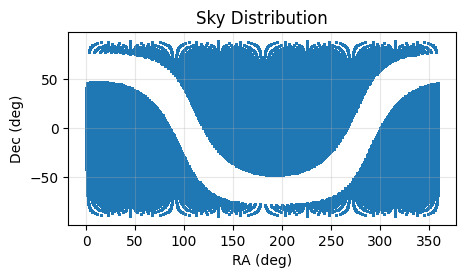

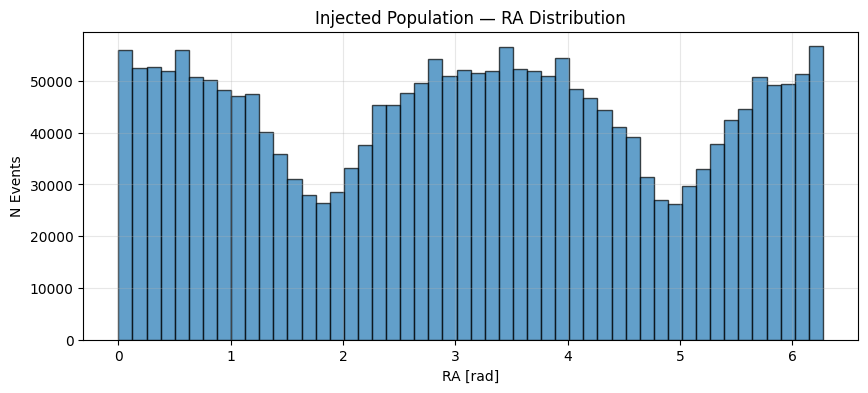

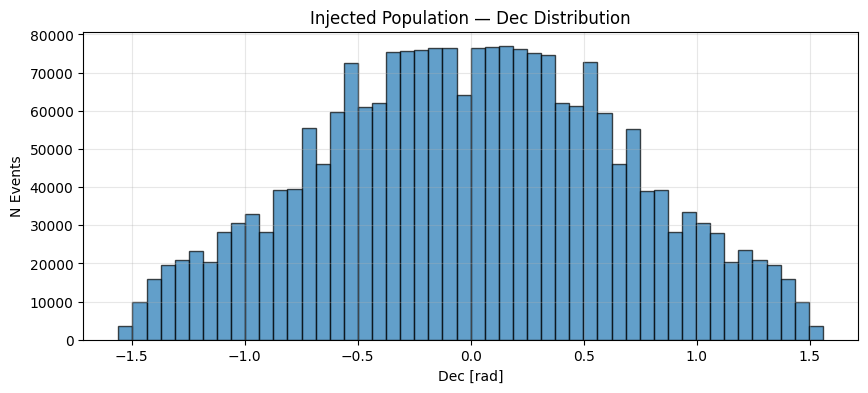

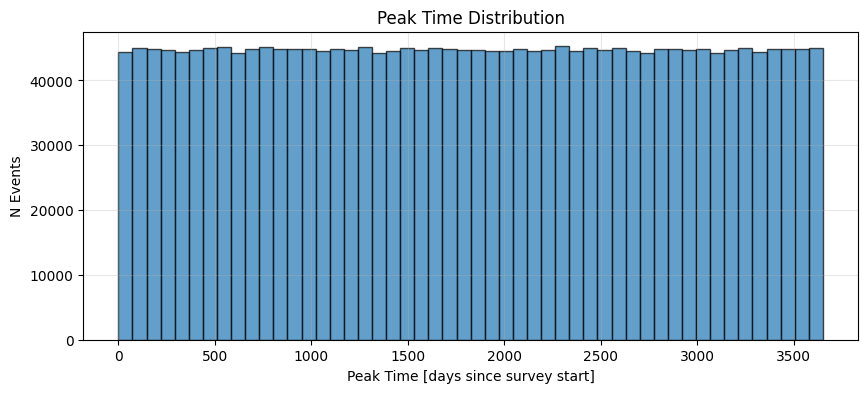

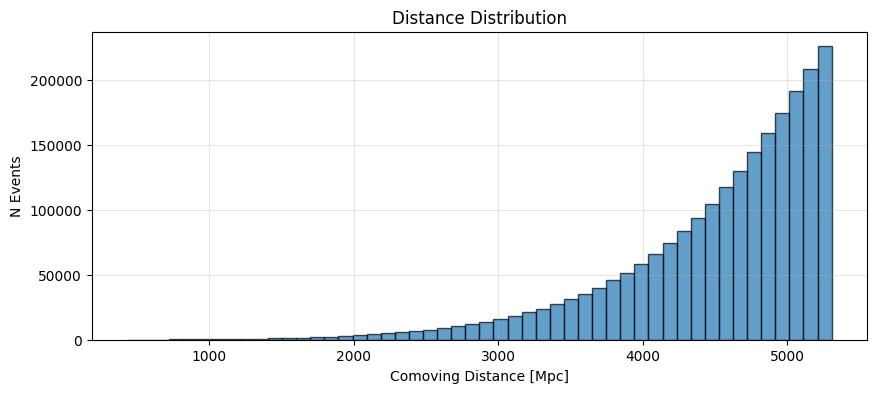

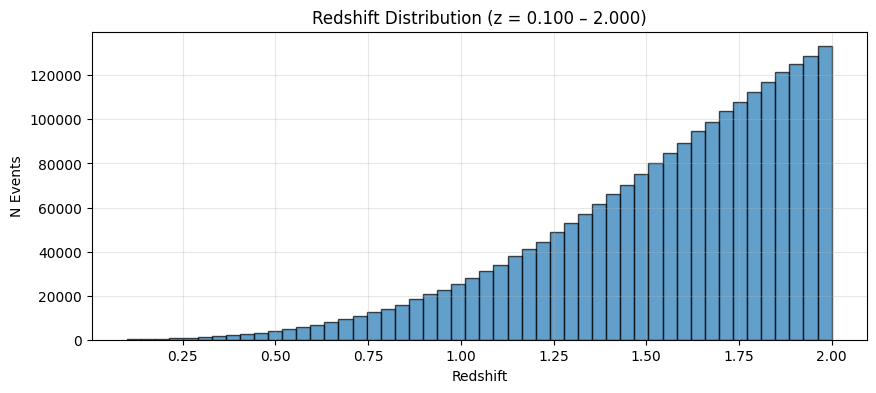

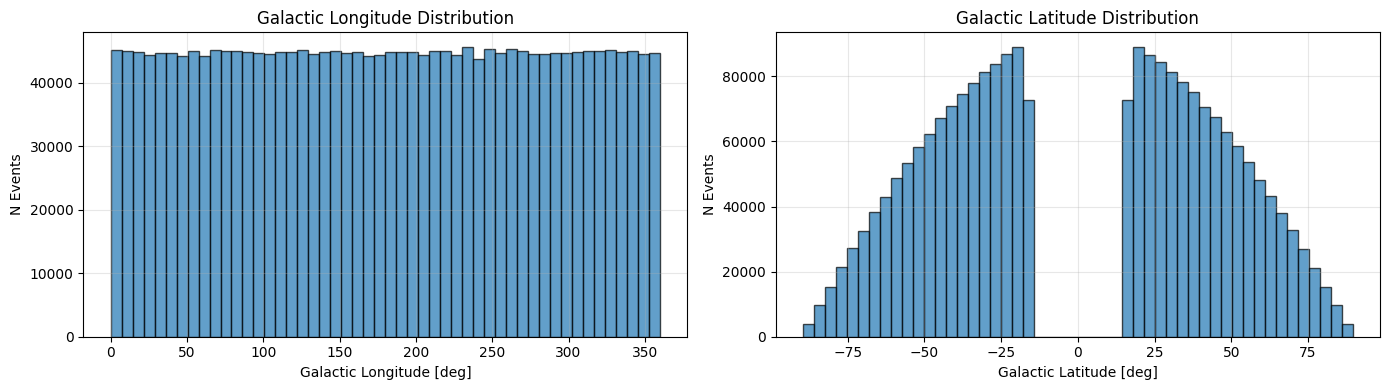

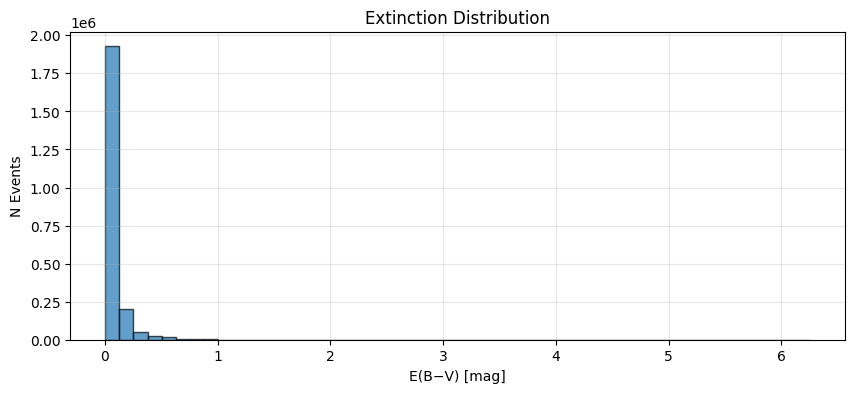

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/fe_dependent_physical

=== Population diagnostics complete ===


In [4]:
# ============================================================================
# CELL B: Population diagnostics — all 3 models
# Loads templates and population slicers for diagnostics.
# Also caches pop_slicers dict for Cells C and D.
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

# Load templates (needed by generate_SLSN_PopSlicer)
print('Loading physical templates...')
templates = LC(load_from=str(SHARED_DIR / 'physical_templates.pkl'))
templates.load_magnitude_grid(str(SHARED_DIR / 'physical_mag_grid.pkl'))
print(f'Templates loaded: {len(templates.sed_grid)} events')

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    pop_slicers[model] = pop
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )
    print(f'  Diagnostics saved to {model_dir}')

print('\n=== Population diagnostics complete ===')


In [6]:
# ============================================================================
# CELL 2: Build combined DataFrame from adaptive results
# Columns: z_lo, z_hi, cadence, metric, n_events, n_success, efficiency,
#          sigma, model, per_year, cadence_short, model_label
# ============================================================================

cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
}
model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}

rows = []
for model, df_adap in ADAPTIVE.items():
    df_s = df_adap.copy()
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)
df_all['model_label']   = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')
print(f'Cadences present: {df_all["cadence"].unique().tolist()}')
print(f'Z-bins: {df_all["z_lo"].nunique()} unique bins')
print(f'\nSample rows:')
print(df_all[df_all['metric']=='SLSN_ELAsTiCC_Metric'].head(4).to_string())

Loaded 1760 rows across 3 models
Metrics present: ['SLSN_Detect_Physical_Metric', 'SLSN_Characterize_Physical_Metric', 'SLSN_Villar_Physical_Metric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTrigger_Physical_Metric']
Cadences present: ['poor_weather_v5.0.1_10yrs', 'baseline_v5.3.0_10yrs', 'noroll_v5.0.0_10yrs', 'baseline_v5.1.1_10yrs']
Z-bins: 16 unique bins

Sample rows:
                      cadence                metric  n_events  n_success  efficiency  z_lo  z_hi     sigma           model  per_year    cadence_short           model_label
3   poor_weather_v5.0.1_10yrs  SLSN_ELAsTiCC_Metric       585        300    0.512821   0.1   0.2  0.020666  naive_physical      30.0     poor_weather  Naive SFR (Physical)
8       baseline_v5.3.0_10yrs  SLSN_ELAsTiCC_Metric       585        316    0.540171   0.1   0.2  0.020606  naive_physical      31.6  baseline v5.3.0  Naive SFR (Physical)
13        noroll_v5.0.0_10yrs  SLSN_ELAsTiCC_Metric       585        321    0.548718   0.1   0.2  0.020574  naive_ph

In [8]:
# ============================================================================
# CELL 3: Summary table — detections/yr and efficiency, all combinations
# Sums n_success across all z-bins per model × cadence × metric
# ============================================================================

METRIC_NAMES = {
    'SLSN_Detect_Physical_Metric':       'Detect',
    'SLSN_Characterize_Physical_Metric': 'Characterize',
    'SLSN_Villar_Physical_Metric':       'Villar',
    'SLSN_ELAsTiCC_Metric':              'ELAsTiCC',
    'SLSN_SpecTrigger_Physical_Metric':  'SpecTrigger',
}

# Aggregate across z-bins: sum n_success, sum n_events per model×cadence×metric
agg = df_all.groupby(['model_label', 'cadence_short', 'metric']).agg(
    n_success=('n_success', 'sum'),
    n_events=('n_events',  'sum'),
).reset_index()
agg['per_year']   = agg['n_success'] / SURVEY_YEARS
agg['efficiency'] = agg['n_success'] / agg['n_events']
agg['metric_short'] = agg['metric'].map(METRIC_NAMES)

CADENCE_ORDER = ['baseline v5.1.1', 'baseline v5.3.0', 'noroll', 'poor_weather']
MODEL_ORDER   = ['Naive SFR (Physical)', 'O-dependent (Physical)', 'Fe-dependent (Physical)']

for metric_full, metric_short in METRIC_NAMES.items():
    sub = agg[agg['metric'] == metric_full]
    if sub.empty:
        print(f'No data for {metric_short}')
        continue

    pivot = sub.pivot_table(
        index='model_label',
        columns='cadence_short',
        values='per_year',
        aggfunc='first'
    ).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER)

    print(f'\n=== {metric_short} — detections per year ===')
    print(pivot.round(1).to_string())

# Overall efficiency summary for Detect
print('\n=== Detect — overall efficiency [%] (all z-bins combined) ===')
det = agg[agg['metric'] == 'SLSN_Detect_Physical_Metric']
pivot_eff = det.pivot_table(
    index='model_label',
    columns='cadence_short',
    values='efficiency',
    aggfunc='first'
).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER) * 100
print(pivot_eff.round(3).to_string())


=== Detect — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)               693.8            701.2   769.6         600.0
O-dependent (Physical)             683.2            693.0   771.6         594.2
Fe-dependent (Physical)            823.0            823.4   919.8         720.8

=== Characterize — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)               467.8            468.2   535.6         395.6
O-dependent (Physical)             462.8            463.6   529.2         394.0
Fe-dependent (Physical)            542.8            542.4   618.4         455.0

=== Villar — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather


In [10]:
# ============================================================================
# CELL C: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell B (no reload needed).
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {model_labels[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Naive SFR (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1238     3.25e+09        3.81e-08       3.20e-08       1.19e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      4627     9.22e+09        5.02e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     31209     4.05e+10        7.70e-08            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01     78241     6.83e+10        1.15e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    260912     1.57e+11        1.66e-07       9.10e-08       1.83e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00    374121     1.86e+11        2.02e-07            NaN            NaN         —


Model: O-dependent (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50

SED spot check — apparent mags from synthesize_mag_at_z()
 event     z  filt      mag
--------------------------------
     0   0.3     g   29.275
     0   0.3     r   28.050
     0   0.3     i   27.432
     0   0.3     z   27.124
     0   1.5     g   41.339
     0   1.5     r   38.008
     0   1.5     i   35.878
     0   1.5     z   34.625
     0   3.0     g   51.520
     0   3.0     r   47.753
     0   3.0     i   44.401
     0   3.0     z   42.351
     1   0.3     g   26.930
     1   0.3     r   25.723
     1   0.3     i   25.389
     1   0.3     z   25.253
     1   1.5     g   38.138
     1   1.5     r   35.313
     1   1.5     i   33.505
     1   1.5     z   32.394
     1   3.0     g   47.642
     1   3.0     r   43.747
     1   3.0     i   40.987
     1   3.0     z   39.286
     2   0.3     g   24.872
     2   0.3     r   24.002
     2   0.3     i   23.775
     2   0.3     z   23.701
     2   1.5     g   34.836
     2   1.5     r   32.498
     2   1.5     i   31.051
     2   1.5 

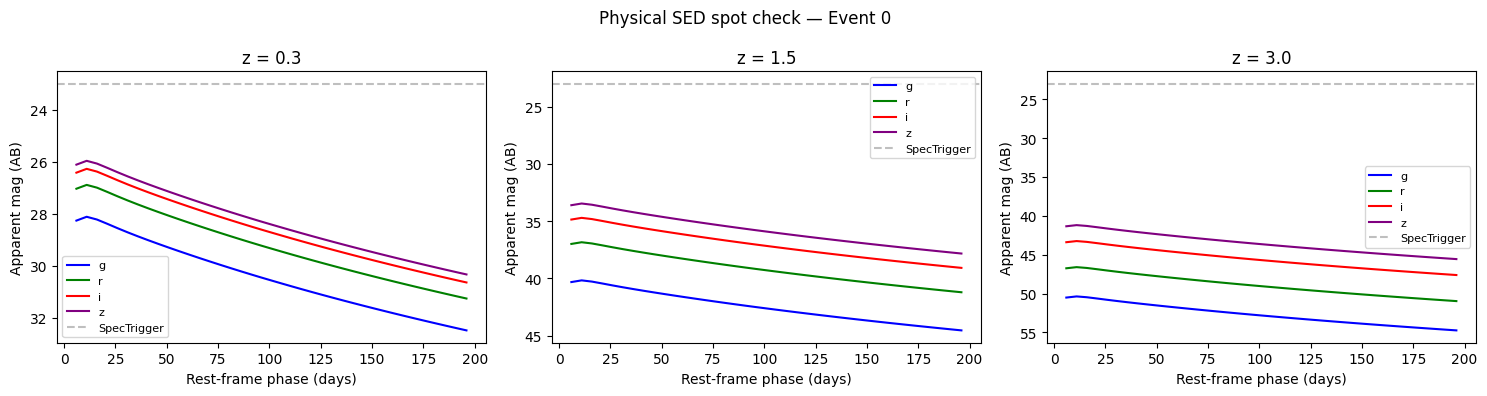

In [12]:
# SED spot check — physical track only
# Verify synthesize_mag_at_z() produces sensible magnitudes
# at representative redshifts before trusting metric results.
# GP templates do not use this code path.

from slsn_metrics.model import synthesize_mag_at_z

test_redshifts = [0.3, 1.5, 3.0]
test_phase     = 50.0   # mid-range post-peak phase
test_filters   = ['g', 'r', 'i', 'z']
n_events_check = 5

print('SED spot check — apparent mags from synthesize_mag_at_z()')
print(f'{"event":>6} {"z":>5} {"filt":>5} {"mag":>8}')
print('-' * 32)
for ev_idx in range(n_events_check):
    sed_entry = templates.sed_grid[ev_idx]
    for z_test in test_redshifts:
        for filt in test_filters:
            m = synthesize_mag_at_z(sed_entry, test_phase, z_test, filt)
            status = f'{m:.3f}' if np.isfinite(m) else 'NaN'
            print(f'{ev_idx:>6} {z_test:>5.1f} {filt:>5} {status:>8}')

# Light curve plot at three redshifts for event 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phases_plot = np.arange(1, 200, 5).astype(float)
filt_colors = {'g': 'blue', 'r': 'green', 'i': 'red', 'z': 'purple'}
for ax, z_test in zip(axes, test_redshifts):
    sed_entry = templates.sed_grid[0]
    for filt, col in filt_colors.items():
        mags_plot = np.array([synthesize_mag_at_z(sed_entry, ph, z_test, filt)
                              for ph in phases_plot])
        finite = np.isfinite(mags_plot)
        if finite.sum() > 0:
            ax.plot(phases_plot[finite], mags_plot[finite], color=col, label=filt)
    ax.invert_yaxis()
    ax.set_xlabel('Rest-frame phase (days)')
    ax.set_ylabel('Apparent mag (AB)')
    ax.set_title(f'z = {z_test}')
    ax.axhline(23.0, ls='--', color='gray', alpha=0.5, label='SpecTrigger')
    ax.legend(fontsize=8)
plt.suptitle('Physical SED spot check — Event 0')
plt.tight_layout()
plt.savefig(get_output_dir('SLSNe', subdir='physical_figures') / 'sed_spot_check.png', dpi=150)
plt.show()


Saved: physical_eff_vs_z_baseline_v5.1.1_10yrs.png


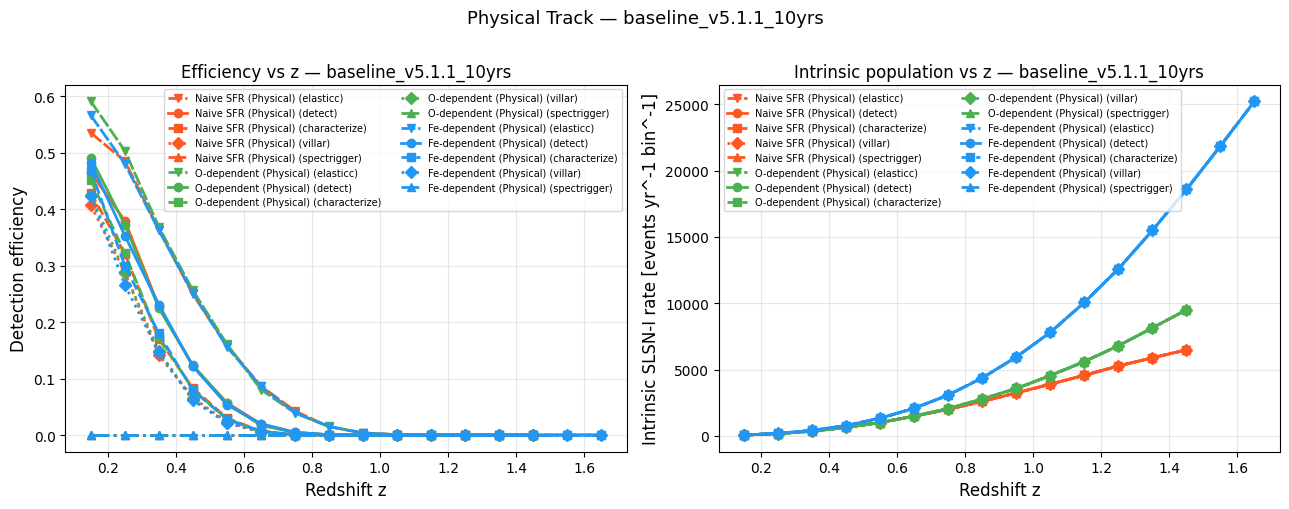

Saved: physical_eff_vs_z_baseline_v5.3.0_10yrs.png


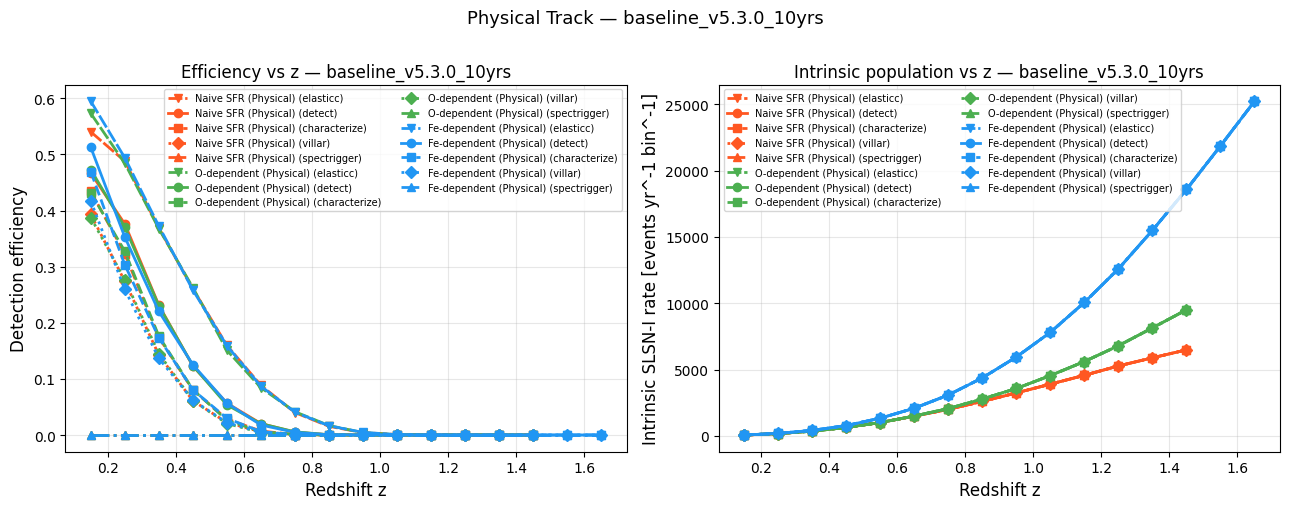

Saved: physical_eff_vs_z_noroll_v5.0.0_10yrs.png


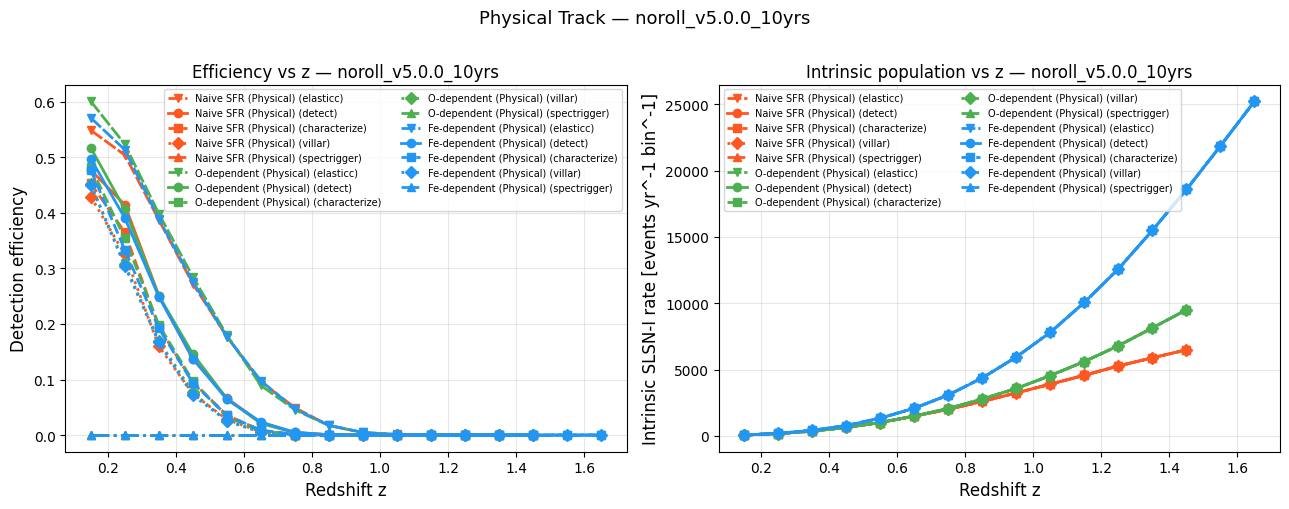

Saved: physical_eff_vs_z_poor_weather_v5.0.1_10yrs.png


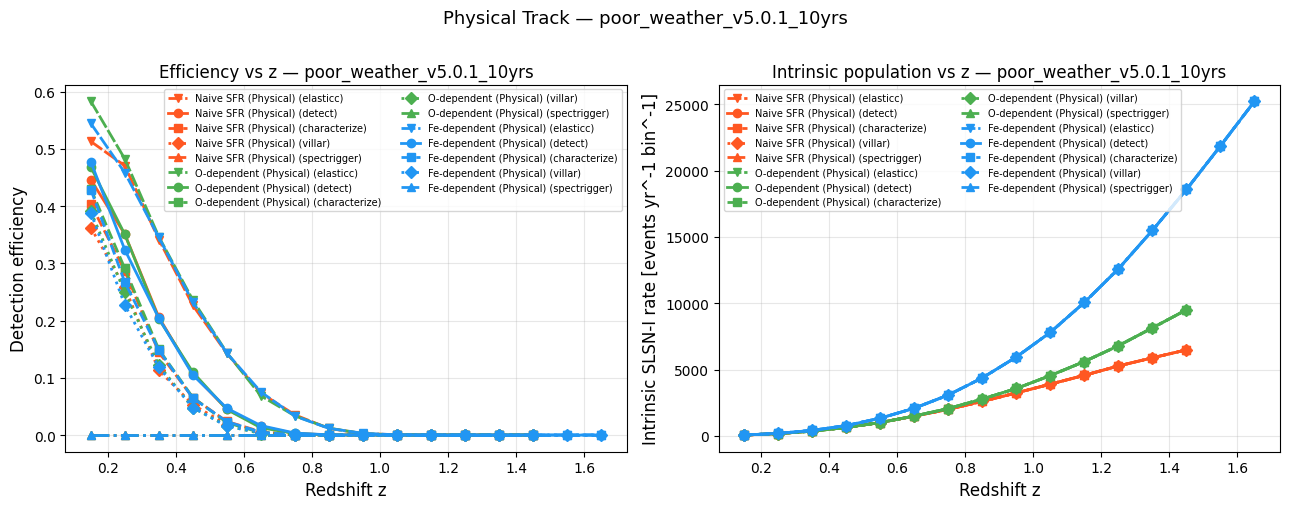

In [14]:
# ============================================================================
# CELL 7: Efficiency vs redshift — all 3 models x all cadences x all metrics
# Reads directly from adaptive results — full population per z-bin.
# ============================================================================

model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}
colors_model = {
    'naive_physical':        '#FF5722',
    'o_dependent_physical':  '#4CAF50',
    'fe_dependent_physical': '#2196F3',
}
metric_keys_z = ['elasticc', 'detect', 'characterize', 'villar', 'spectrigger']
ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'spectrigger':  '-.',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'spectrigger':  '^',
    'villar':       'D',
    'elasticc':     'v',
}

for cadence in CADENCES:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model in MODELS:
        if model not in pop_data:
            continue
        z_centers = pop_data[model]['z_centers']

        for metric in metric_keys_z:
            entry = pop_data[model][metric].get(cadence)
            if entry is None:
                continue
            eff_bins   = entry['efficiency']
            n_ev_bins  = entry['n_events']
            count_bins = [n / SURVEY_YEARS for n in n_ev_bins]

            label = f'{model_labels[model]} ({metric})'
            axes[0].plot(z_centers, eff_bins,
                         marker=markers_metric[metric],
                         color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)
            axes[1].plot(z_centers, count_bins,
                         marker=markers_metric[metric],
                         color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)

    for ax in axes:
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {cadence}', fontsize=12)
    axes[1].set_ylabel('Intrinsic SLSN-I rate [events yr^-1 bin^-1]', fontsize=12)
    axes[1].set_title(f'Intrinsic population vs z — {cadence}', fontsize=12)

    plt.suptitle(f'Physical Track — {cadence}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'physical_eff_vs_z_{cadence}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()



naive_physical: 376,227 events at z=0.1-1.5

--- naive_physical x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_naive_physical_baseline_v5.1.1_10yrs_physical.png
  Saved: healpix_characterize_naive_physical_baseline_v5.1.1_10yrs_physical.png
  Saved: healpix_villar_naive_physical_baseline_v5.1.1_10yrs_physical.png


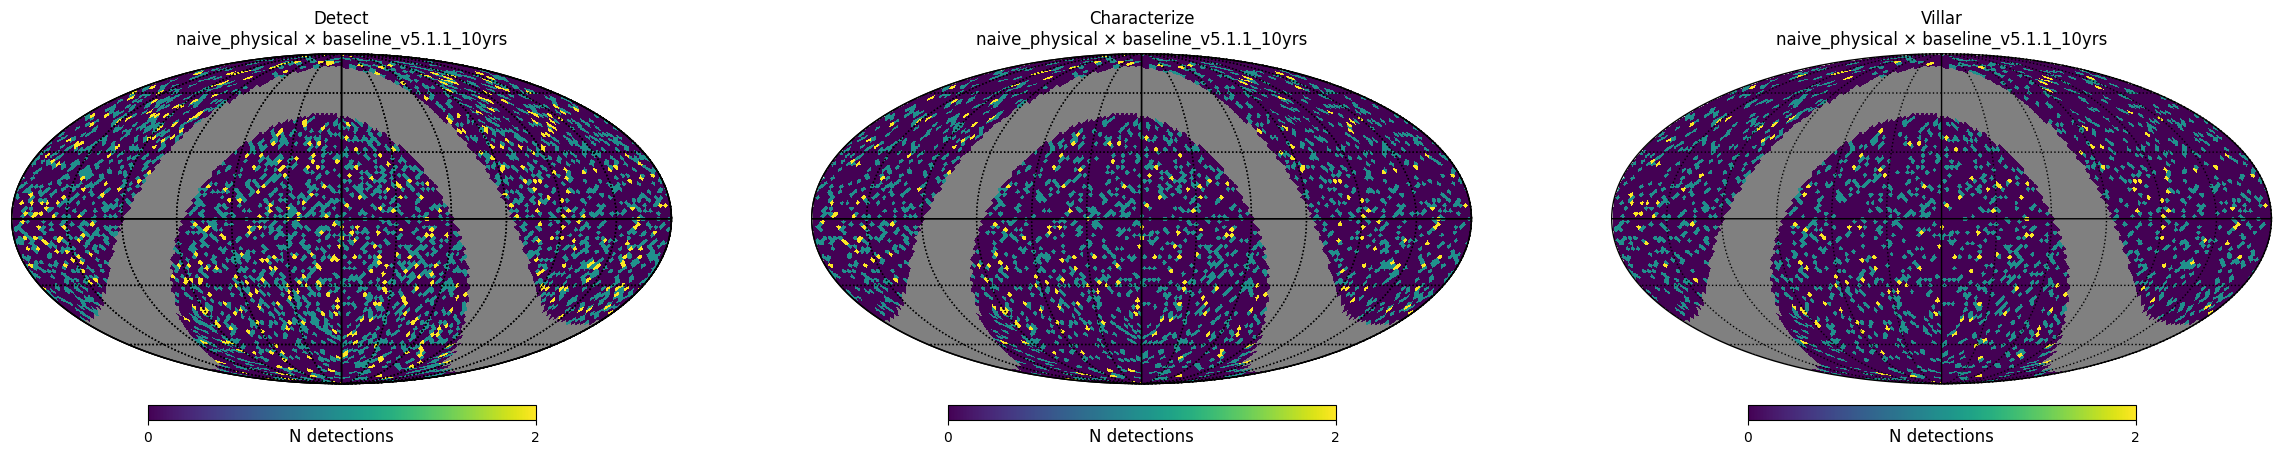

  Saved row: healpix_row_naive_physical_baseline_v5.1.1_10yrs_physical.png

--- naive_physical x baseline_v5.3.0_10yrs ---
  Saved: healpix_detect_naive_physical_baseline_v5.3.0_10yrs_physical.png
  Saved: healpix_characterize_naive_physical_baseline_v5.3.0_10yrs_physical.png
  Saved: healpix_villar_naive_physical_baseline_v5.3.0_10yrs_physical.png


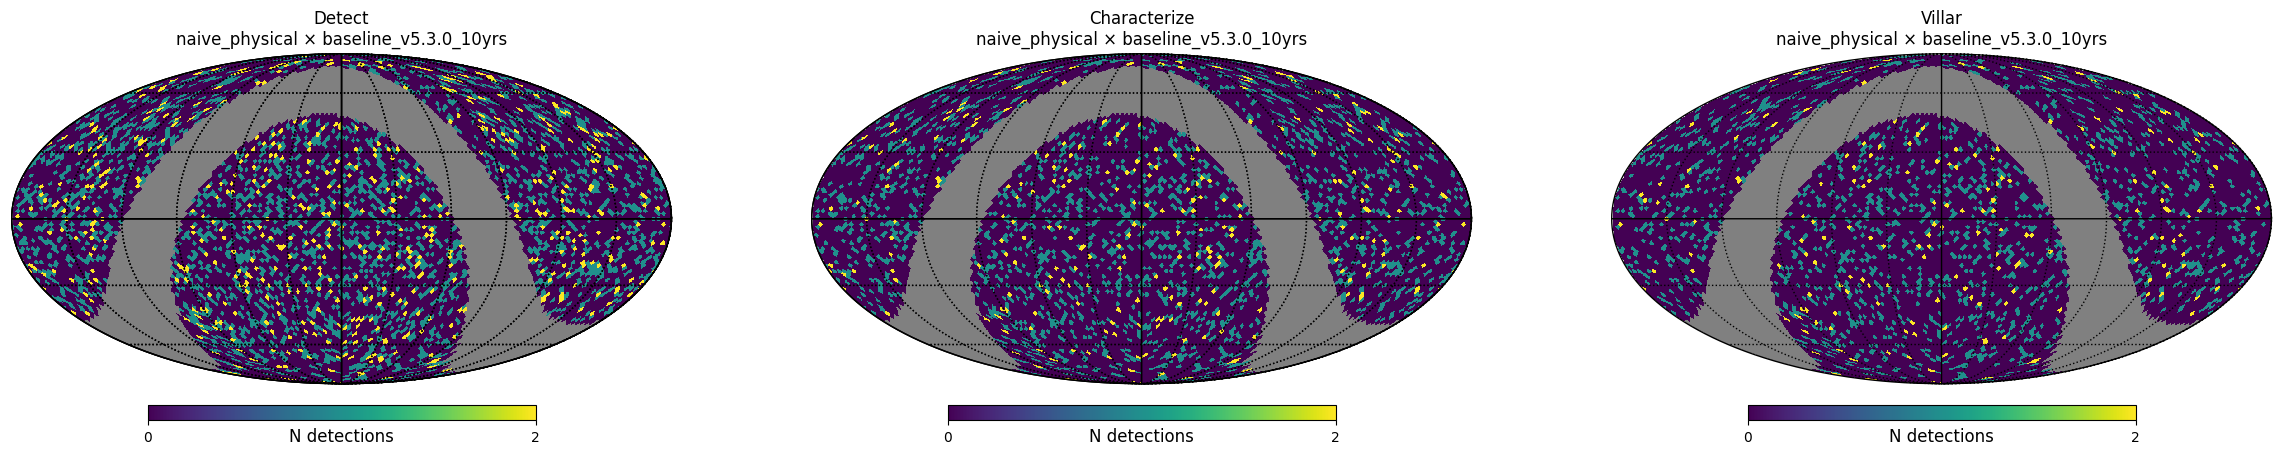

  Saved row: healpix_row_naive_physical_baseline_v5.3.0_10yrs_physical.png

--- naive_physical x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_physical_noroll_v5.0.0_10yrs_physical.png
  Saved: healpix_characterize_naive_physical_noroll_v5.0.0_10yrs_physical.png
  Saved: healpix_villar_naive_physical_noroll_v5.0.0_10yrs_physical.png


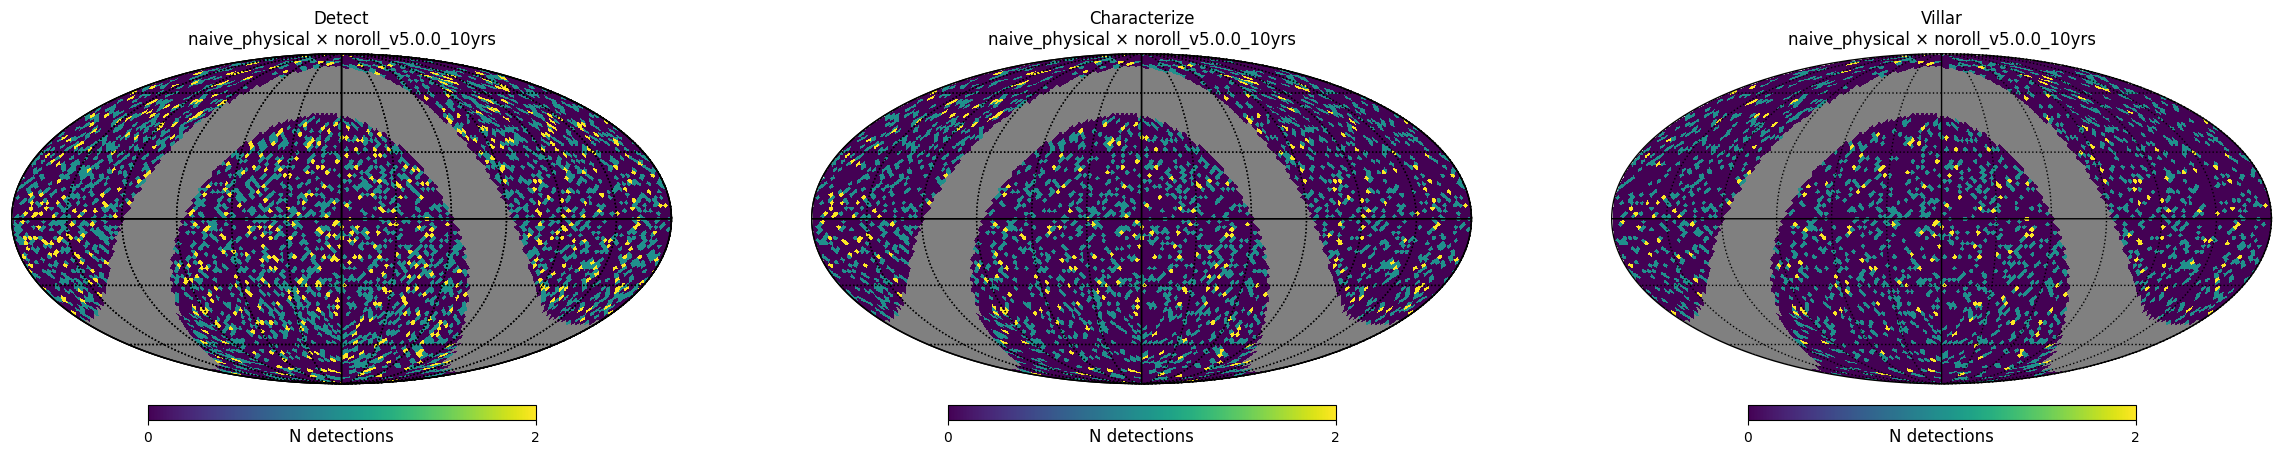

  Saved row: healpix_row_naive_physical_noroll_v5.0.0_10yrs_physical.png

--- naive_physical x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_naive_physical_poor_weather_v5.0.1_10yrs_physical.png
  Saved: healpix_characterize_naive_physical_poor_weather_v5.0.1_10yrs_physical.png
  Saved: healpix_villar_naive_physical_poor_weather_v5.0.1_10yrs_physical.png


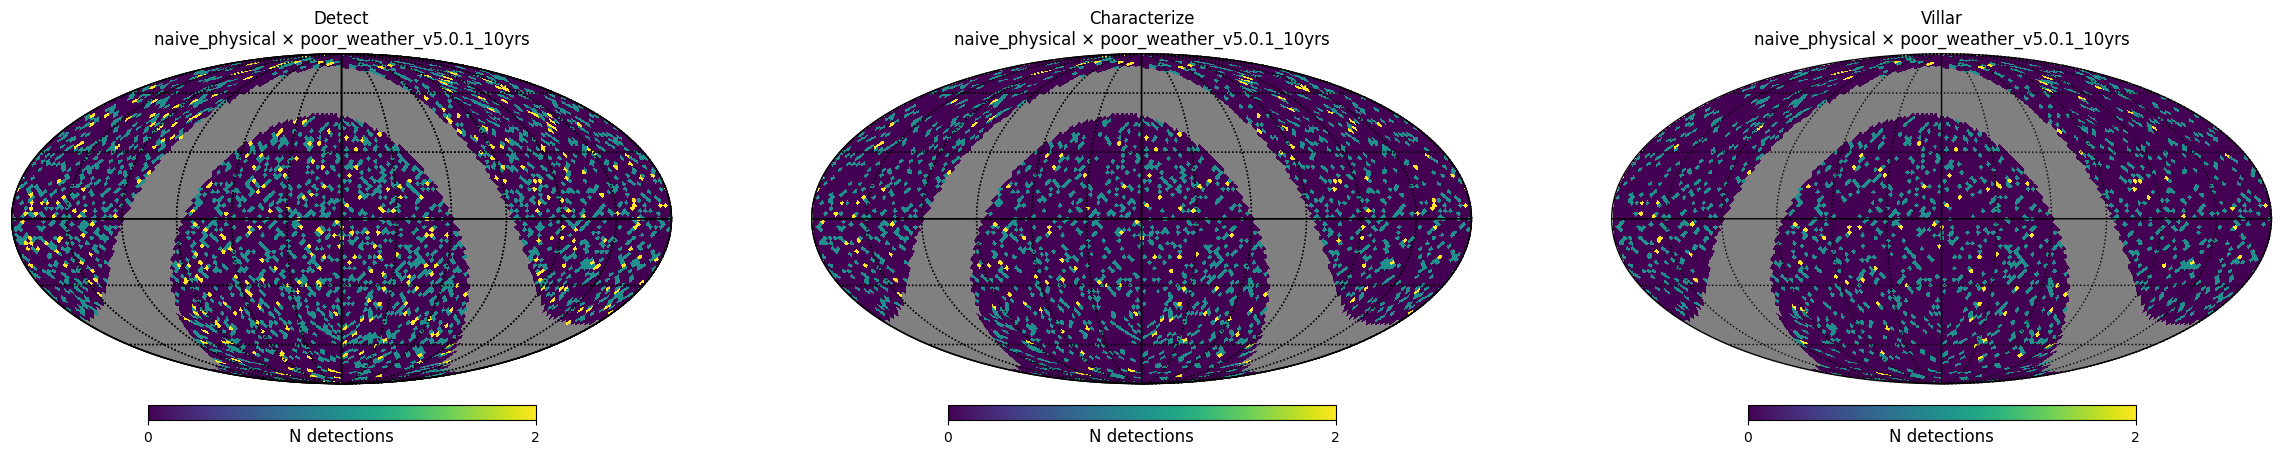

  Saved row: healpix_row_naive_physical_poor_weather_v5.0.1_10yrs_physical.png

o_dependent_physical: 466,780 events at z=0.1-1.5

--- o_dependent_physical x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png
  Saved: healpix_characterize_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png
  Saved: healpix_villar_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png


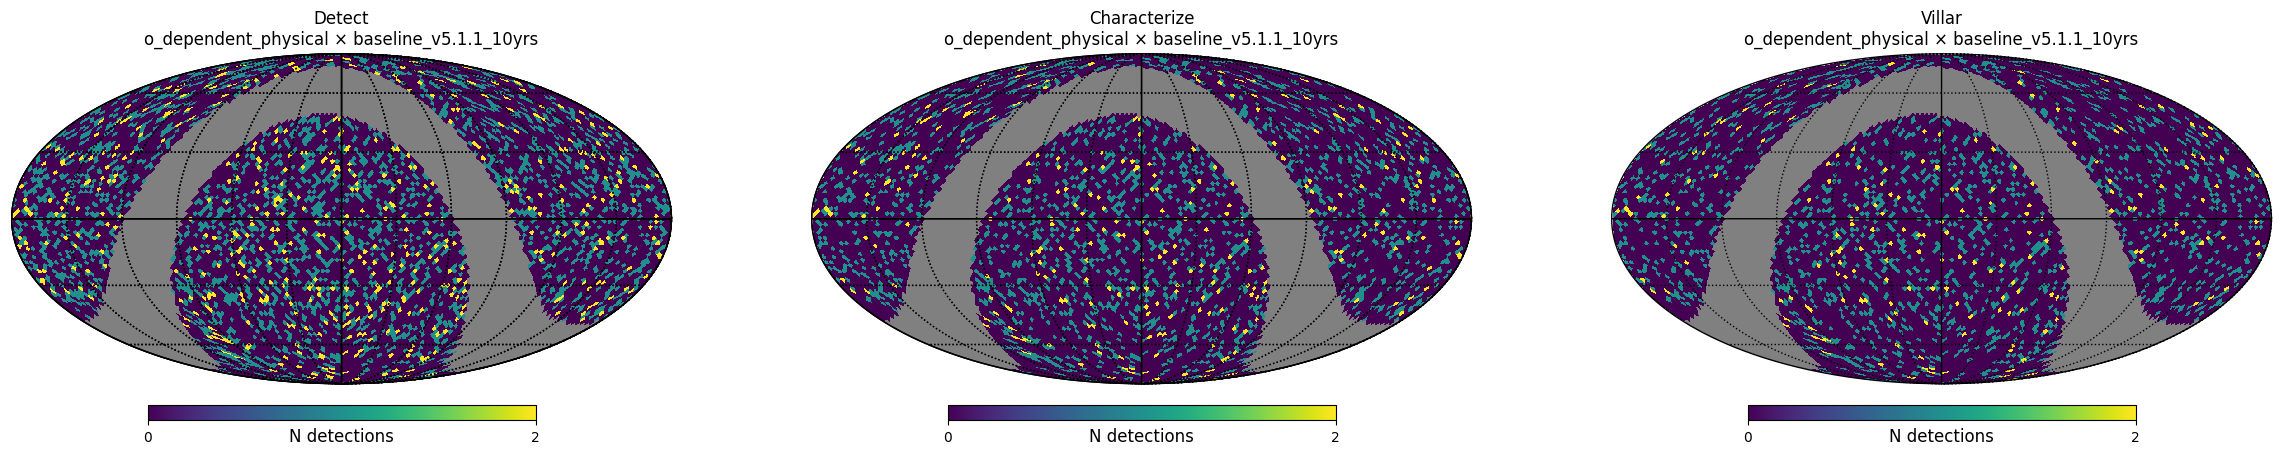

  Saved row: healpix_row_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- o_dependent_physical x baseline_v5.3.0_10yrs ---
  Saved: healpix_detect_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png
  Saved: healpix_characterize_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png
  Saved: healpix_villar_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png


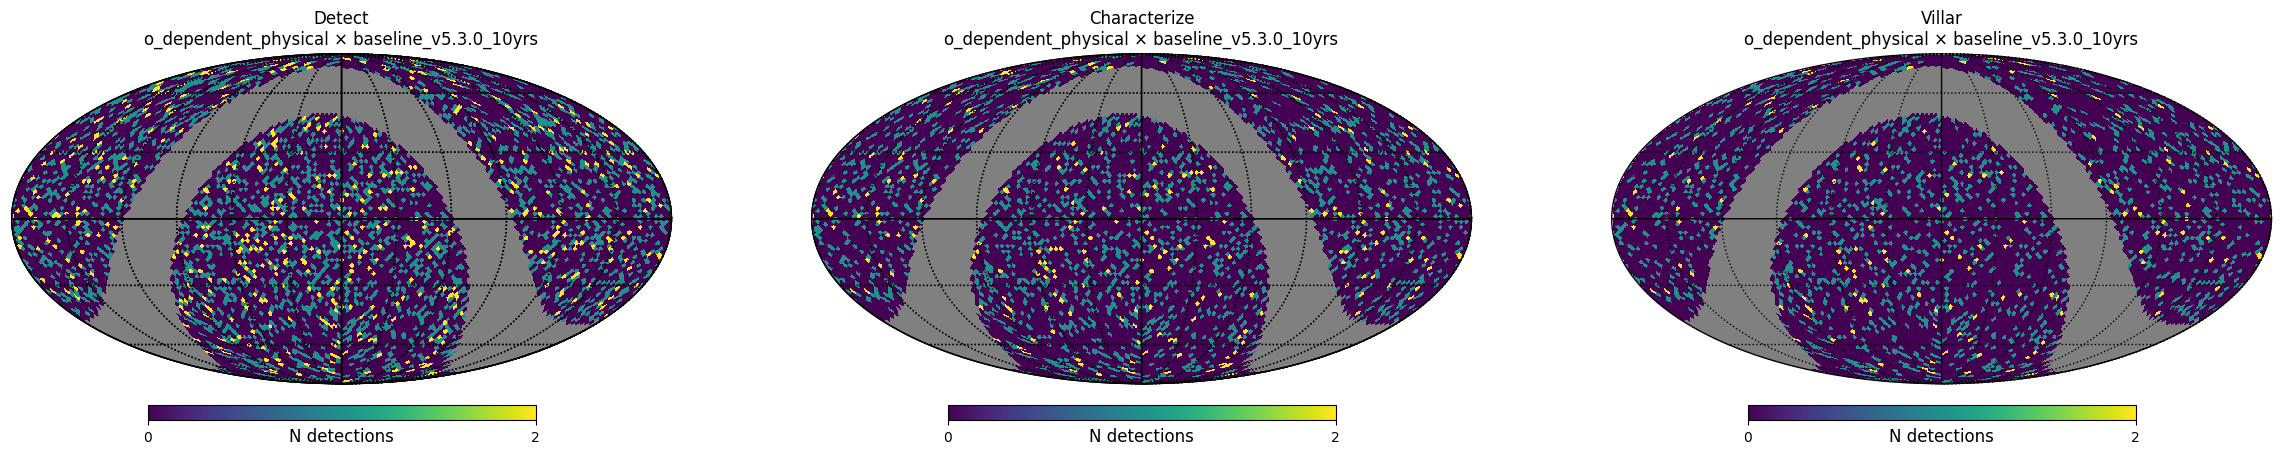

  Saved row: healpix_row_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png

--- o_dependent_physical x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_physical_noroll_v5.0.0_10yrs_physical.png
  Saved: healpix_characterize_o_dependent_physical_noroll_v5.0.0_10yrs_physical.png
  Saved: healpix_villar_o_dependent_physical_noroll_v5.0.0_10yrs_physical.png


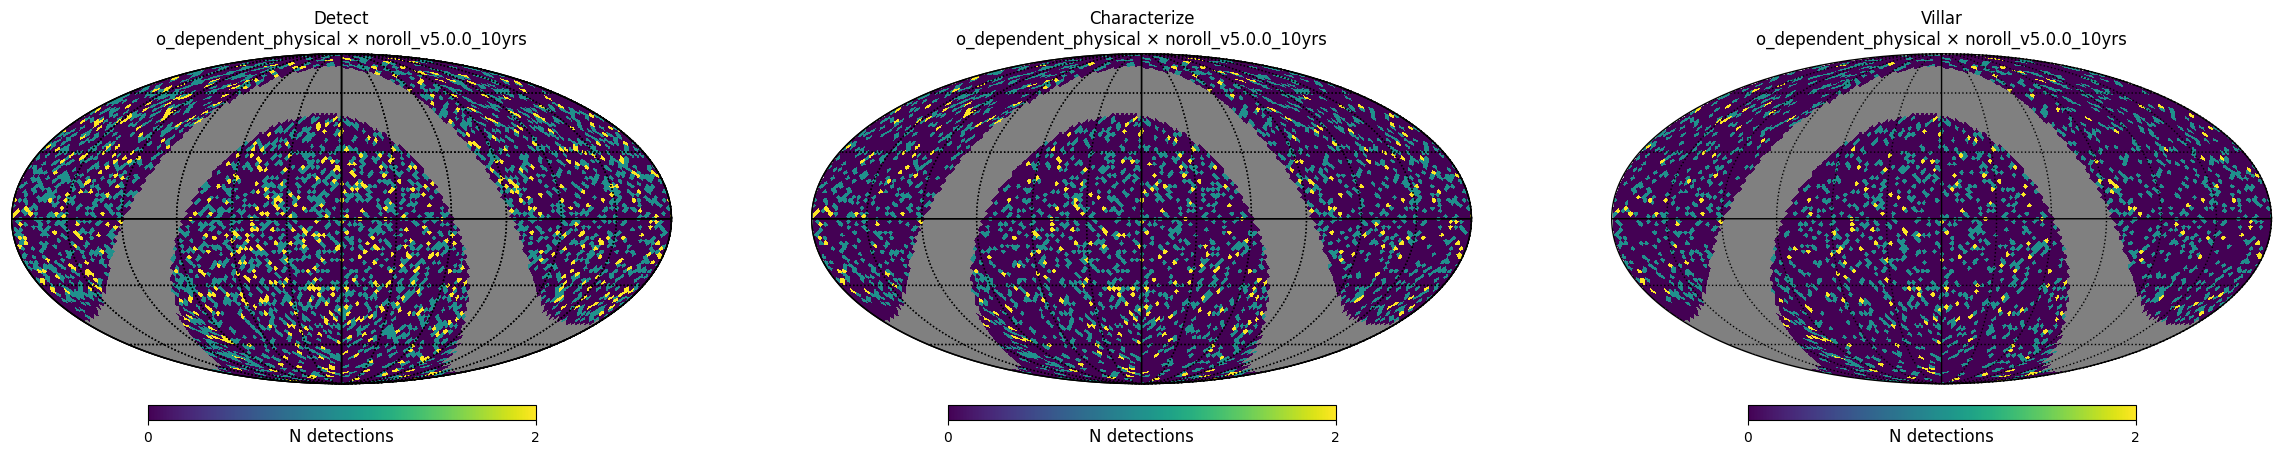

  Saved row: healpix_row_o_dependent_physical_noroll_v5.0.0_10yrs_physical.png

--- o_dependent_physical x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_o_dependent_physical_poor_weather_v5.0.1_10yrs_physical.png
  Saved: healpix_characterize_o_dependent_physical_poor_weather_v5.0.1_10yrs_physical.png
  Saved: healpix_villar_o_dependent_physical_poor_weather_v5.0.1_10yrs_physical.png


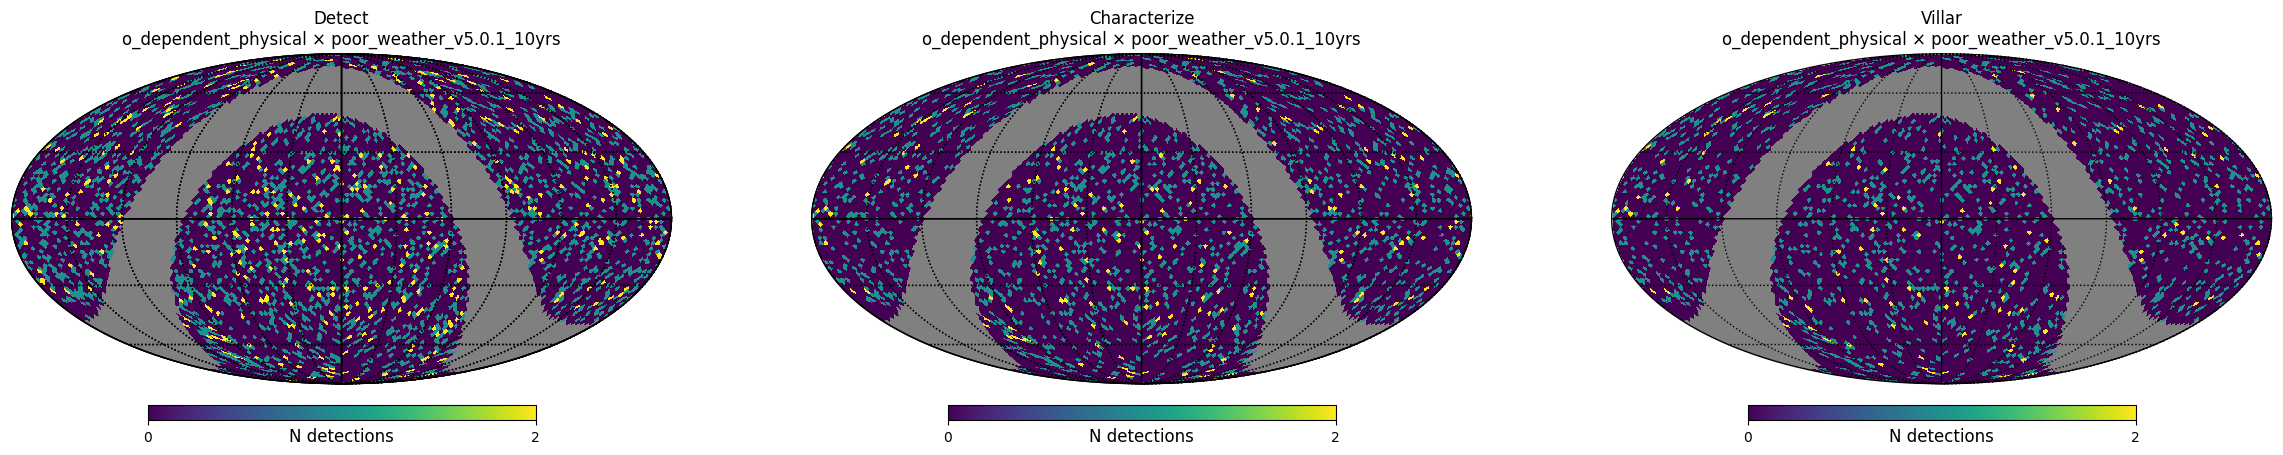

  Saved row: healpix_row_o_dependent_physical_poor_weather_v5.0.1_10yrs_physical.png
fe_dependent_physical: no matching adaptive .npy — skipping


In [27]:
# ============================================================================
# CELL 9: HEALPix sky maps — all 3 models × all 4 cadences
# Shows raw detection counts per pixel over 10-year survey.
# Grey = outside Rubin footprint or galactic plane cut.
# Purple = injected but zero detections.
# Yellow = many detections (scale = 95th percentile of detected pixels).
# ============================================================================
reload(diag_mod)
import healpy as hp

METRIC_KEYS     = ["detect", "characterize", "villar"]
HEALPIX_FIGSIZE = (24, 4)
NSIDE           = 32

for model in MODELS:
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find z_max that matches adaptive .npy size
    z_max_used = None
    for z_max_try in [1.7, 1.5]:
        test_npy = get_output_dir('SLSNe', subdir=model) / \
                   f'metric_values_elasticc_{model}_noroll_v5.0.0_10yrs_z0.1-{z_max_try}_adaptive.npy'
        if test_npy.exists():
            test_arr = np.load(str(test_npy))
            mask_try = (z_all >= 0.1) & (z_all <= z_max_try)
            if len(test_arr) == mask_try.sum():
                z_max_used = z_max_try
                mask_z     = mask_try
                break
    if z_max_used is None:
        print(f'{model}: no matching adaptive .npy — skipping')
        continue

    ra_map  = np.asarray(sp['ra'])[mask_z]
    dec_map = np.asarray(sp['dec'])[mask_z]
    print(f'\n{model}: {mask_z.sum():,} events at z=0.1-{z_max_used}')

    # Precompute pixel indices once per model (same for all cadences/metrics)
    npix  = hp.nside2npix(NSIDE)
    theta = 0.5 * np.pi - dec_map
    pix   = hp.ang2pix(NSIDE, theta, ra_map)

    # Injected map — same for all metrics
    injected_map = np.zeros(npix)
    for p in pix:
        injected_map[p] += 1
    footprint = injected_map > 0

    for cadence in CADENCES:
        print(f"\n--- {model} x {cadence} ---")
        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            npy_path = get_output_dir('SLSNe', subdir=model) / \
                       f'metric_values_{metric}_{model}_{cadence}_z0.1-{z_max_used}_adaptive.npy'
            if not npy_path.exists():
                print(f"  Skipping {metric} — {npy_path.name} not found")
                continue

            metric_map = np.load(str(npy_path)).astype(int)
            if len(metric_map) != len(ra_map):
                print(f"  Size mismatch: npy={len(metric_map)}, "
                      f"pop={len(ra_map)} — skipping {metric}")
                continue

            # Build raw detection count map
            detected_map = np.zeros(npix)
            for i, p in enumerate(pix):
                if metric_map[i] == 1:
                    detected_map[p] += 1

            # Map: UNSEEN outside footprint, count inside
            count_map = np.full(npix, hp.UNSEEN)
            count_map[footprint] = detected_map[footprint]

            # Colorscale: 0 to 95th percentile of pixels that have detections
            detected_pixels = detected_map[footprint & (detected_map > 0)]
            if len(detected_pixels) > 0:
                vmax = float(np.percentile(detected_pixels, 95))
            else:
                vmax = 1.0

            hp.mollview(
                count_map,
                title  = f"{metric.capitalize()}\n{model} × {cadence}",
                unit   = 'N detections',
                cmap   = 'viridis',
                min    = 0,
                max    = vmax,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

            out_healpix = get_output_dir('SLSNe', subdir=model) / \
                          f'healpix_{metric}_{model}_{cadence}_physical.png'
            print(f"  Saved: {out_healpix.name}")

        out_row = get_output_dir('SLSNe', subdir=model) / \
                  f'healpix_row_{model}_{cadence}_physical.png'
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  Saved row: {out_row.name}")

In [28]:
# Quick check — load GP detect .npy and check spatial distribution
import numpy as np, pickle
from pathlib import Path

# Find GP naive detect file
gp_files = sorted(
    Path('output/SLSNe/naive').glob(
        'metric_values_detect_naive_noroll*.npy'),
    key=lambda f: f.stat().st_mtime)

if not gp_files:
    print("No GP naive detect files found")
else:
    arr = np.load(str(gp_files[-1]))
    print(f"GP file: {gp_files[-1].name}")
    print(f"N events: {len(arr):,}, N detected: {arr.sum():.0f}, rate: {arr.mean()*100:.3f}%")
    
    # Load matching population
    with open('output/SLSNe/shared/population_naive.pkl','rb') as f:
        pop = pickle.load(f)
    z_gp  = np.asarray(pop['z'])
    ra_gp = np.degrees(np.asarray(pop['ra']))
    dec_gp = np.degrees(np.asarray(pop['dec']))
    
    # Match size
    if len(arr) == len(z_gp):
        det = arr > 0
        print(f"\nGP detection rate by Dec zone:")
        print(f"  South (Dec<-30):     {det[dec_gp<-30].mean()*100:.3f}%")
        print(f"  Equatorial (-30,10): {det[(dec_gp>=-30)&(dec_gp<10)].mean()*100:.3f}%")
        print(f"  North (Dec>+10):     {det[dec_gp>10].mean()*100:.3f}%")
    else:
        print(f"Size mismatch: arr={len(arr)}, pop={len(z_gp)}")

GP file: metric_values_detect_naive_noroll_v5.0.0_10yrs_z0.1-2.0_260409_0307.npy
N events: 750,598, N detected: 3785, rate: 0.504%

GP detection rate by Dec zone:
  South (Dec<-30):     0.802%
  Equatorial (-30,10): 0.792%
  North (Dec>+10):     0.078%


In [ ]:
# ============================================================================
# CELL 10 - MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO — peak_time already in pop_data from Cell 6
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggle METRIC_KEY to switch which detection stage is plotted.
# Produces one figure per cadence, each with:
#   Top    : N(SLSNe) — all 3 models with 68% CI bands
#   Bottom : Significance — fe vs naive, o vs naive, fe vs o
# ============================================================================

import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

# --- Toggle this to switch metric ---
METRIC_KEY   = 'detect'        # options: 'detect', 'characterize', 'spectrigger'
                               # Note: 'villar' and 'elasticc' are not appropriate here —
                               # they encode photometric classifier scores, not detection
                               # counts, and cannot be interpreted as absolute rates.
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'spectrigger':  'Spec Triggers',
}[METRIC_KEY]

SAVE_DIR = get_output_dir('SLSNe', subdir=MODELS[0])

for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )